# Hypixel Skyblock - Difference in Differences Analysis

### Exploring the causal effect of marketplace price changes to Hypixel server store on in-game booster cookie prices. 

## Composed Commodity Control Index

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

sys.path.append(os.path.abspath('..'))
from scripts.market_api import data_pull
from scripts.data_construction import data_construction

# Define the precise API registry endpoints for all major counterfactual assets
missing_gems = {
    'perfect_amber_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_AMBER_GEM/history',
    'perfect_topaz_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_TOPAZ_GEM/history',
    'perfect_sapphire_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_SAPPHIRE_GEM/history',
    'perfect_amethyst_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_AMETHYST_GEM/history',
    'perfect_jasper_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_JASPER_GEM/history',
    'perfect_ruby_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_RUBY_GEM/history',
    'perfect_jade_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_JADE_GEM/history',
    'perfect_opal_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_OPAL_GEM/history',
    'perfect_aquamarine_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_AQUAMARINE_GEM/history',
    'perfect_citrine_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_CITRINE_GEM/history',
    'perfect_onyx_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_ONYX_GEM/history',
    'perfect_peridot_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_PERIDOT_GEM/history',
}

In [ ]:
print("Executing parallel API data ingestion layer...\n")
period = 145 # Full Availible Data

# Ensure the raw directory exists so data_pull doesn't throw an OS error
os.makedirs("data/raw", exist_ok=True)

for name, url in missing_gems.items():
    # Force the output destination directly into the target data path
    output_path = f"{name}_market_historical.csv"
    
    print(f"Pulling {name.upper()}... Calling data_pull()")
    
    # Run your core ingestion script
    data_pull(url, output_path)

print("\nAll raw CSV matrices successfully downloaded and structured inside data/raw/!")

print("Building Composed Commodity Control Index...\n")

# Treatment Group (Booster Cookies)
path_cookie = "data/raw/cookie_market_historical.csv"

cleaned_cookie_data = data_construction(path_cookie).tail(period).reset_index(drop=True)
cleaned_cookie_data['timestamp'] = pd.to_datetime(cleaned_cookie_data['timestamp'])

# Synthetic Control Group Construction 
gem_list = [
    'PERFECT_TOPAZ_GEM', 'PERFECT_RUBY_GEM', 'PERFECT_SAPPHIRE_GEM', 
    'PERFECT_AMBER_GEM', 'PERFECT_JADE_GEM', 'PERFECT_AMETHYST_GEM',
    'PERFECT_AQUAMARINE_GEM', 'PERFECT_CITRINE_GEM', 'PERFECT_JASPER_GEM',
    'PERFECT_ONYX_GEM', 'PERFECT_PERIDOT_GEM', 'PERFECT_SAPPHIRE_GEM'
]

gem_data_frames = []

for gem in gem_list:
    # Handle the fact that your Topaz file is saved as 'gemstone_market_historical.csv'
    if gem == 'PERFECT_TOPAZ_GEM':
        path = "data/raw/gemstone_market_historical.csv"
    else:
        path = f"data/raw/{gem.lower()}_market_historical.csv"
        
    if os.path.exists(path):
        df = data_construction(path).tail(period).reset_index(drop=True)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df[['timestamp', 'buy']].rename(columns={'buy': f'buy_{gem}'})
        gem_data_frames.append(df)
    else:
        print(f"Warning: Base data for {gem} not found at {path}. Skipping from index...")

# Merge all available gemstone vectors on exact timestamp alignment
composite_gems = gem_data_frames[0]
for df in gem_data_frames[1:]:
    composite_gems = pd.merge(composite_gems, df, on='timestamp', how='inner')

# Average across columns to isolate pure, market-wide mining sector inflation
buy_cols = [col for col in composite_gems.columns if 'buy_' in col]
composite_gems['buy'] = composite_gems[buy_cols].mean(axis=1)

cleaned_gemstone_data = composite_gems[['timestamp', 'buy']].copy()
print(f"Successfully aggregated {len(buy_cols)} perfect gemstone markets into a single index.")

Executing parallel API data ingestion layer...

Pulling PERFECT_AMBER_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_TOPAZ_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_SAPPHIRE_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_AMETHYST_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_JASPER_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_RUBY_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_JADE_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_OPAL_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_AQUAMARINE_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_CITRINE_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_ONYX_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_PERIDOT_GEM... Calling data_pull()
Success: 500 entries saved.

All raw CSV mat

In [ ]:
print("Assembling 3-day binned panel structure...")

# Ensure timestamps are set as the datetime index for resampling
cleaned_cookie_data['timestamp'] = pd.to_datetime(cleaned_cookie_data['timestamp'])
cleaned_gemstone_data['timestamp'] = pd.to_datetime(cleaned_gemstone_data['timestamp'])

# Bin by 3-Day Intervals
# Resample using a 3-day frequency ('3D') and take the mean price over that block
cookie_binned = cleaned_cookie_data.set_index('timestamp').resample('3D').mean().reset_index()
gem_binned = cleaned_gemstone_data.set_index('timestamp').resample('3D').mean().reset_index()

# Drop any potential NaN intervals introduced if there were gaps in the underlying API pull
cookie_binned = cookie_binned.dropna(subset=['buy']).reset_index(drop=True)
gem_binned = gem_binned.dropna(subset=['buy']).reset_index(drop=True)

# Assign Experiment Indicators
cookie_binned['Treatment'] = 1
cookie_binned['Asset'] = 'Booster Cookie'

gem_binned['Treatment'] = 0
gem_binned['Asset'] = 'Composite Gemstone Index'

# Concatenate the binned series into long-format panel
panel_df = pd.concat([cookie_binned, gem_binned], axis=0, ignore_index=True)

# Code Policy Dummies & Trends
# Post-shock indicator based on the start of the 3-day bin window
panel_df['Post'] = (panel_df['timestamp'] >= '2026-04-15').astype(int)
panel_df['DiD_Interaction'] = panel_df['Treatment'] * panel_df['Post']
panel_df['log_buy'] = np.log(panel_df['buy'])

# Continuous linear time trend (scaled in units of 3-day periods)
min_date = panel_df['timestamp'].min()
panel_df['time_trend'] = (panel_df['timestamp'] - min_date).dt.total_seconds() / (24 * 3600 * 3)

print(f"Binned panel alignment complete. Total aggregated observations: {len(panel_df)}")

Assembling 3-day binned panel structure...
Binned panel alignment complete. Total aggregated observations: 99


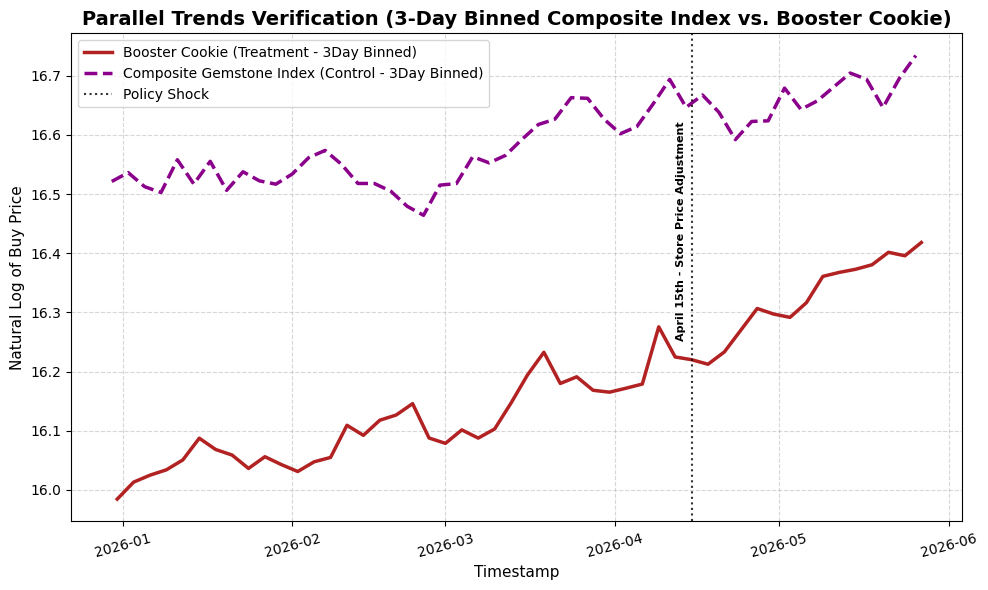

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.transforms as transforms

fig, ax1 = plt.subplots(figsize=(10, 6))

# Filter the long-format panel data back into its respective groups for plotting
binned_cookie = panel_df[panel_df['Treatment'] == 1].sort_values('timestamp')
binned_gemstone = panel_df[panel_df['Treatment'] == 0].sort_values('timestamp')

# Plot 3-Day Binned Treatment Group (Booster Cookies)
ax1.plot(binned_cookie['timestamp'], binned_cookie['log_buy'], 
         label='Booster Cookie (Treatment - 3Day Binned)', color='firebrick', linewidth=2.5)

# Plot 3-Day Binned Control Group (Composite Gemstone Index)
ax1.plot(binned_gemstone['timestamp'], binned_gemstone['log_buy'], 
         label='Composite Gemstone Index (Control - 3Day Binned)', color='darkmagenta', 
         linewidth=2.5, linestyle='--')

# Add a vertical visual indicator for the policy shock date (April 15, 2026)
shock_date = pd.to_datetime('2026-04-15')
ax1.axvline(shock_date, color='black', linestyle=':', alpha=0.8, linewidth=1.5, label='Policy Shock')

# April 15th Label
trans = transforms.blended_transform_factory(ax1.transData, ax1.transAxes)
ax1.text(shock_date - pd.Timedelta(days=1), 0.82, 
         'April 15th - Store Price Adjustment', 
         transform=trans, 
         rotation=90, 
         verticalalignment='top', 
         horizontalalignment='right',
         fontsize=8, 
         fontweight='bold', 
         color='black',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Formatting & Titles
ax1.set_title('Parallel Trends Verification (3-Day Binned Composite Index vs. Booster Cookie)', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Timestamp', fontsize=11)
ax1.set_ylabel('Natural Log of Buy Price', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [7]:
# Newey-West Econometric Estimation 
print("\nEstimating Fixed Effects Panel Model with Newey-West HAC Standard Errors...")
model_composite = smf.ols(formula="log_buy ~ Treatment + Post + DiD_Interaction + time_trend", data=panel_df).fit(
    cov_type='HAC', 
    cov_kwds={'maxlags': 4}
)

print(model_composite.summary())


Estimating Fixed Effects Panel Model with Newey-West HAC Standard Errors...
                            OLS Regression Results                            
Dep. Variable:                log_buy   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     1116.
Date:                Thu, 28 May 2026   Prob (F-statistic):           2.84e-78
Time:                        18:18:07   Log-Likelihood:                 186.28
No. Observations:                  99   AIC:                            -362.6
Df Residuals:                      94   BIC:                            -349.6
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------